**TẢI TẬP DỮ LIỆU DATA_NLP VÀ QUAN SÁT TẬP DỮ LIỆU**

---

In [1]:
#Gọi các thư viện:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#-----------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Đọc file dữ liệu Data_NLP.csv vào biến data
data =  pd.read_csv("data/Data_NLP.csv")
data

,class,tweet
0,0,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...
56695,1,i couldn't end #2016 without mentioning #trump...
56696,0,#chateaubriand #stovells absolutely lovely #fo...
56697,0,@user #frarou woohoo! #euro2016 kicks off..!
56698,0,and here i thought @user and i were having a ...


**Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp:**

---

In [3]:
#Kiểm tra dữ liệu missing trong tập: 
data.isnull().sum()

class    0
tweet    0
dtype: int64

In [4]:
#Kiểm tra dữ liệu trùng lặp:
data.duplicated().sum()

2429

In [5]:
#Liệt kê các bản ghi trùng lặp
data[data.duplicated()==True].sort_values(by='tweet')

,class,tweet
37332,0,#fathersday ! looking for something to do? s...
56547,0,#fathersday ! looking for something to do? s...
52183,0,#fathersday ! looking for something to do? s...
47075,0,#fathersday ! looking for something to do? s...
55171,0,#friday! we look forward to a wonderful week...
...,...,...
48366,0,ð #tech 10 symptoms of having a paner obs...
50083,0,ð #tech how bitcoin will revolutionise ga...
34745,0,ðquote of the day ð #bless #thankful #o...
28937,0,ðquote of the day ð #bless #thankful #o...


In [6]:
#Xóa các dữ liệu trùng lặp giữ lại bản ghi đầu tiên:
data.drop_duplicates(keep='first',inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54271 entries, 0 to 56699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   54271 non-null  int64 
 1   tweet   54271 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.2+ MB


TIỀN XỬ LÝ DỮ LIỆU VĂN BẢN
---

Sử dụng thư viện Natural Language Tool Kit (NLTK) thực hiện xử lý các comment

NLTK là một bộ công cụ dành riêng cho Natural Language Processing và được tích hợp vào Python. Nó đang ngày càng hoàn thiện và tích hợp các công cụ mới bởi hàng nghìn lập trình viên và cộng tác viên trên khắp thế giới. NLTK bao gồm những thư viện hàm, các công cụ phân tích, các corpus, wordnet, …giúp đơn giản hóa, tiết kiệm thời gian và công sức cho các lập trình viên. Python kết hợp với NLTK là bộ công cụ hữu hiệu và mạnh mẽ nhất dành cho Natural Language Processing.

http://www.nltk.org/

In [7]:
#Khai báo sử dụng thư viện NLTK
import nltk
# nltk.download('punkt')
nltk.download('wordnet')
#nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

print(nltk.__version__)

3.8.1


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Làm sạch dữ liệu
---
Mục đích bước này là loại bỏ noise trong data . Đa phần noise là các thẻ HTML, JavaScript, và đương nhiên nếu cứ để noise để tiến hành xử lý sẽ dẫn đến kết quả xử lý không tốt.

Thư viện re — Regular expression operations: thao tác với biểu thức chính quy

https://regex101.com/

In [8]:
#Thư viện re — Regular expression operations: thao tác với biểu thức chính quy
import re

#hàm decontracted thực hiện chuyển đổi các phần viết tắt thành câu đầy đủ
def decontracted(st):
    # specific
    st = re.sub(r"won\'t", "will not", st)
    st = re.sub(r"can\'t", "can not", st)
    # general
    st = re.sub(r"n\'t", " not", st)
    st = re.sub(r"\'re", " are", st)
    st = re.sub(r"\'s", " is", st)
    st = re.sub(r"\'d", " would", st)
    st = re.sub(r"\'ll", " will", st)
    st = re.sub(r"\'ve", " have", st)
    st = re.sub(r"\'m", " am", st)
    return st

In [9]:
#Kiểm tra decontracted:
text=""""SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com"""

print("Dữ liệu ban đầu: \n", text)
print('-----------------------------------------------')

text1 = decontracted(text)
print("Dữ liệu sau khi xử lý: \n", text1)

Dữ liệu ban đầu: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com
-----------------------------------------------
Dữ liệu sau khi xử lý: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That is the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I am looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com


In [10]:
 #hàm clear_link thực hiện loại bỏ liên kết (link), địa chỉ email trong câu
def clear_link(st):
    #Remove links/email
    word = re.sub(r'((http|https)\:\/\/)?[a-zA-Z0-9\.\/\?\:@\-_=#]+\.([a-zA-Z]){2,6}([a-zA-Z0-9\.\&\/\?\:@\-_=#])*', 
                '', st, flags=re.MULTILINE)
    word = re.sub(r'(@[^\s]*)', "", word)
    #word = re.sub('[\W]', ' ', st)
    return word

In [11]:
#Kiểm tra clear_link:
print("Dữ liệu ban đầu: \n", text)
print('-----------------------------------------------')

text1 = clear_link(text)
print("Dữ liệu sau khi xử lý: \n", text1)

Dữ liệu ban đầu: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com
-----------------------------------------------
Dữ liệu sau khi xử lý: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
; 


In [12]:
#Hàm clear_punctuation thực hiện loai bỏ các dấu câu, ký tự đặc biệt trong chuỗi
def clear_punctuation(st):
    word = re.sub(r'[^\w\s]', '',st)
    return word

In [13]:
#Kiểm tra clear_punctuation:
print("Dữ liệu ban đầu: \n", text)
print('-----------------------------------------------')

text1 = clear_punctuation(text)
print("Dữ liệu sau khi xử lý: \n", text1)

Dữ liệu ban đầu: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com
-----------------------------------------------
Dữ liệu sau khi xử lý: 
 SORRY JB FAN 65292REALLY JUSTIN COME BACK 
Thats the top comment on a Justin Timberlake video with 10 million views 
Son of a fucking bitch Im looking forward this video Have you been seen it yet 
fanjustingmailcom httpsallflimcom


In [14]:
#Hàm clear_special loại bỏ các ký tự chỉ để lại các ký tự chữ a-z, A-Z
def clear_special(st):
    word = re.sub('[^a-zA-Z]', ' ', st)
    return word

In [15]:
#Kiểm tra clear_special:
print("Dữ liệu ban đầu: \n", text)
print('-----------------------------------------------')

text1 = clear_special(text)
print("Dữ liệu sau khi xử lý: \n", text1)

Dữ liệu ban đầu: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That's the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com
-----------------------------------------------
Dữ liệu sau khi xử lý: 
  SORRY JB FAN         REALLY JUSTIN COME BACK    That s the top comment on a Justin Timberlake video with    million views   Son of a fucking bitch  I m looking forward this video  Have you been seen it yet   fanjustin gmail com  https   allflim com


In [16]:
#Hàm clear_noise kết hợp sử dụng các hàm ở trên để xử lý chuỗi
def clear_noise(word):
    word = word.lower()         # chuyển toàn bộ sang chữ thường để xử lý
    word = decontracted(word)
    word = clear_link(word)
    word = clear_punctuation(word)
    word = clear_special(word)
    return word

In [17]:
#Kiểm tra clear_noise:
text=""""SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That is the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com"""

print("Dữ liệu ban đầu: \n", text)
print('-----------------------------------------------')
text1 = clear_noise(text)
print("Dữ liệu sau khi làm sạch: \n", clear_noise(text1))

Dữ liệu ban đầu: 
 "SORRY JB FAN &#65292;REALLY JUSTIN COME BACK". 
That is the top comment on a Justin Timberlake video with 10 million views. 
Son of a fucking bitch! I'm looking forward this video. Have you been seen it yet. 
fanjustin@gmail.com; https://allflim.com
-----------------------------------------------
Dữ liệu sau khi làm sạch: 
 sorry jb fan      really justin come back  that is the top comment on a justin timberlake video with    million views  son of a fucking bitch i am looking forward this video have you been seen it yet   


### Loại bỏ stopword
---

StopWords là những từ xuất hiện nhiều trong ngôn ngữ tự nhiên, tuy nhiên lại không mang nhiều ý nghĩa. Ở tiếng việt StopWords là những từ như: để, này, kia... Tiếng anh là những từ như: is, that, this... Tham khảo thêm tại danh sách stopwords trong tiếng việt

Có rất nhiều cách để loại bỏ StopWords nhưng có 2 cách chính là:

* Dùng từ điển

* Dựa theo tần suất xuất hiện của từ

In [18]:
#stopwords là những từ xuất hiện nhiều trong văn bản, nhưng ko có ý nghĩa 
#Load danh sách Stopword trong tiếng anh

#nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

In [19]:
#Hiển thị danh sách các stopwords trong tiếng anh
print('Hiển thị danh sách các stopwords trong tiếng anh:\n',stop)

Hiển thị danh sách các stopwords trong tiếng anh:
 ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over

In [20]:
#hàm clear_stopwords lọai bỏ các từ stopword trong câu
def clear_stopwords(st):
    word = " ".join(st for st in st.split() if st not in stop)
    return word

In [21]:
print('Dữ liệu ban đầu: \n',text1)
print('-------------------------------------')
text2 = clear_stopwords(text1)
print('Dữ liệu loại bỏ stopwords:\n',text2)

Dữ liệu ban đầu: 
 sorry jb fan      really justin come back  that is the top comment on a justin timberlake video with    million views  son of a fucking bitch i am looking forward this video have you been seen it yet   
-------------------------------------
Dữ liệu loại bỏ stopwords:
 sorry jb fan really justin come back top comment justin timberlake video million views son fucking bitch looking forward video seen yet


### Chuẩn hóa từ (Stemming và Lemmatization)
---
Trong quá trình xử lý ngôn ngữ tự nhiên, chúng ta sẽ có nhu cầu so sánh các từ (token) với nhau. Việc so sánh này tưởng chừng như đơn giản là lấy 2 chuỗi ký tự và dùng phép “==” để kiểm tra, nhưng thực tế thì không phải là như vậy. Đối với một số ngôn ngữ, tiêu biểu là tiếng Anh, mỗi từ có thể có nhiều biến thể khác nhau. Điều này làm cho việc so sánh giữa các từ là không thể mặc dù về mặc ý nghĩa cơ bản là như nhau. Ví dụ các từ “walks“, “walking“, “walked” đều là các biến thể của từ “walk” và đều mang ý nghĩa là “đi bộ”. Vậy làm sao để so sánh các từ như thế với nhau? Lemmatization và Stemming chính là 2 kỹ thuật thường được dùng cho việc này.

Stemming là kỹ thuật dùng để biến đổi 1 từ về dạng gốc (được gọi là stem hoặc root form) bằng cách cực kỳ đơn giản là loại bỏ 1 số ký tự nằm ở cuối từ mà nó nghĩ rằng là biến thể của từ. Ví dụ như chúng ta thấy các từ như walked, walking, walks chỉ khác nhau là ở những ký tự cuối cùng, bằng cách bỏ đi các hậu tố –ed, –ing hoặc –s, chúng ta sẽ được từ nguyên gốc là walk. Người ta gọi các bộ xử lý stemming là Stemmer.

Bởi vì nguyên tắc hoạt động của stemmer rất là đơn giản như vậy cho nên tốc độ xử lý của nó rất là nhanh, và kết quả stem đôi khi không được như chúng ta mong muốn. Chẳng hạn như từ goes sẽ được stem thành từ goe (bỏ chữ s cuối từ) trong khi đó stem của từ go vẫn là go, kết quả là 2 từ “goes” và “go” sau khi được stem thì vẫn không giống nhau. Một nhược điểm khác là nếu các từ dạng bất quy tắt như went hay spoke thì stemmer sẽ không thể đưa các từ này về dạng gốc là go hay speak.

Tuy có các nhược điểm như trên nhưng trong thực tế Stemming vẫn được sử dụng khá phổ biến trong NLP vì nó có tốc độ xử lý nhanh và kết quả cuối cùng nhìn chung không hề tệ khi so với Lemmatization.

In [22]:
from nltk.stem import WordNetLemmatizer
wn = WordNetLemmatizer()
import string
my_sw = ['rt', 'ht', 'fb', 'amp', 'gt']

def black_txt(token):
    if token == 'u':
        token = 'you'
    return  token not in stop and token not in list(string.punctuation) and token not in my_sw


def fun_stemlem(word):
    list_word_clean = []
    for w1 in word.split(" "):
        if  black_txt(w1.lower()):
            word_lemma =  wn.lemmatize(w1,  pos="v")
            list_word_clean.append(word_lemma)

  #Cleaning, lowering and remove whitespaces
    word = " ".join(list_word_clean)
    return word 

In [23]:
print('Dữ liệu ban đầu: \n',text2)
print('-------------------------------------')
text3 = fun_stemlem(text2)
print('Dữ liệu sau khi đã chuẩn hóa:\n',text3)

Dữ liệu ban đầu: 
 sorry jb fan really justin come back top comment justin timberlake video million views son fucking bitch looking forward video seen yet
-------------------------------------
Dữ liệu sau khi đã chuẩn hóa:
 sorry jb fan really justin come back top comment justin timberlake video million view son fuck bitch look forward video see yet


### Tiền Xử lý toàn bộ tập dữ liệu với các hàm đã xây dựng
---


In [24]:
#Xây dựng hàm prepare_data: để thực hiện tiền xử lý dữ liệu
def prepare_data(word):
    word = clear_noise(word)        #Loại bỏ nhiễu trong các comment
    word = clear_stopwords(word)    #Loại bỏ stopword trong các comment
    word = fun_stemlem(word)        #Chuẩn hóa comment
    return word

In [25]:
#Hiển thị danh sách các từ trước và sau khi tiền xử lý để test
for idx in data[6095:6100].index:
    print(idx, 
        '\n a.Dữ liệu gốc          :', data.iloc[idx]['tweet'],
        '\n b.Dữ liệu sau chuẩn hóa:',prepare_data(data.iloc[idx]['tweet']))
    print("************")

6095 
 a.Dữ liệu gốc          : @hidalgoparadise lol its #hoe bitch ass 
 b.Dữ liệu sau chuẩn hóa: lol hoe bitch ass
************
6096 
 a.Dữ liệu gốc          : @hiyathanda_alps "that hoe over there" 
 b.Dữ liệu sau chuẩn hóa: hoe
************
6097 
 a.Dữ liệu gốc          : @hmianturner boooooi that's TMI for these hoes 
 b.Dữ liệu sau chuẩn hóa: boooooi tmi hoe
************
6098 
 a.Dữ liệu gốc          : @hoes &#9829; 
 b.Dữ liệu sau chuẩn hóa: 
************
6099 
 a.Dữ liệu gốc          : @holmes0786 only if its yellow cake &amp; chocolate frosting 
 b.Dữ liệu sau chuẩn hóa: yellow cake chocolate frost
************


In [26]:
#Tạo dataframe data_new, bổ sung thêm field: tweet_ok là comment đã được tiền xử lý dữ liệu tương ứng
data_new = data.copy()
data_new['tweet_ok'] = data['tweet'].apply(lambda x: prepare_data(x))

In [27]:
data_new.head(10)

,class,tweet,tweet_ok
0,0,!!! RT @mayasolovely: As a woman you shouldn't...,woman complain clean house man always take trash
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dats dwn bad cuffin dat hoe st place
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg ever fuck bitch start cry confuse shit
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranny
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear might true might faker bitch tell ya
5,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",shit blow faithful somebody still fuck hoe
6,1,"!!!!!!""@__BrighterDays: I can not just sit up ...",sit hate another bitch get much shit go
7,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,cause tire big bitch come us skinny girls
8,1,""" &amp; you might not get ya bitch back &amp; ...",might get ya bitch back thats
9,1,""" @rhythmixx_ :hobbies include: fighting Maria...",hobbies include fight mariam bitch


### lọc và loại bỏ một số comment rỗng sau chuẩn hóa:
---
Sau khi thực hiện tiền xử lý, một số comment chỉ còn lại xâu rỗng, cần loại bỏ những xâu này


In [28]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54271 entries, 0 to 56699
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   class     54271 non-null  int64 
 1   tweet     54271 non-null  object
 2   tweet_ok  54271 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [29]:
#Lọc những comment sau khi xử lý chỉ còn là khoảng trắng
print('Tổng số:',data_new['tweet_ok'].loc[data_new.tweet_ok==r''].count())
data_new.loc[data_new.tweet_ok==r'']

Tổng số: 43


,class,tweet,tweet_ok
2637,1,@BloodOfJupiter yeah...bitch!,
4828,0,@TNKidsFoodPorn @Oreo ..............&#128530;,
6098,1,@hoes &#9829;,
6613,1,@maccabeez thanks...bitch.,
25441,0,..feeling so #lonely..and ..,
26744,0,@user same ððð,
28134,0,what i doð,
28765,0,@user then why are you,
29194,0,no 1 is up,
29582,0,@user @user @user @user @user @user @user @us...,


In [30]:
#Chỉ lấy các bản ghi có dữ liệu:
data_ok = data_new.loc[data_new.tweet_ok!=r'']
data_ok.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54228 entries, 0 to 56699
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   class     54228 non-null  int64 
 1   tweet     54228 non-null  object
 2   tweet_ok  54228 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


### Kiểm tra mức độ cân bằng của tập dữ liệu:
---

In [31]:
#Kiểm tra mức độ cân bằng của tập dữ liệu
print('Thông kê tập dữ liệu:')
print(data_ok.count())
print('-----------------------------------')
print('Thông kê số lượng comment theo lớp:')
x = data_ok['class'].value_counts()
print(x)

Thông kê tập dữ liệu:
class       54228
tweet       54228
tweet_ok    54228
dtype: int64
-----------------------------------
Thông kê số lượng comment theo lớp:
class
0    31609
1    22619
Name: count, dtype: int64


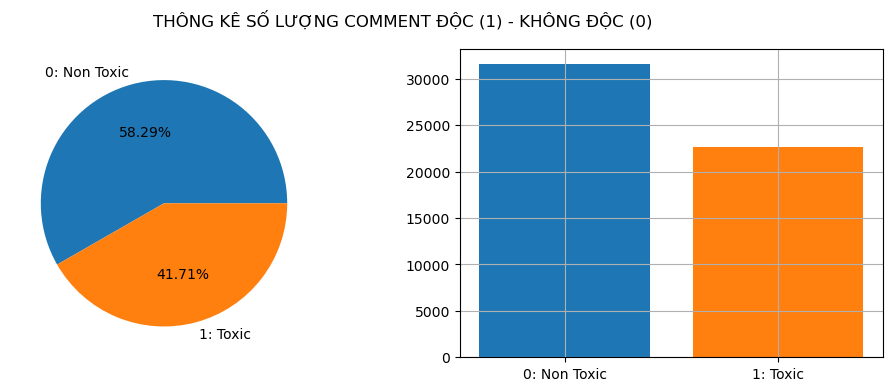

In [32]:
#Trực quan hóa số liệu
import matplotlib.pyplot as plt
label = ['0: Non Toxic', '1: Toxic']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.suptitle('THÔNG KÊ SỐ LƯỢNG COMMENT ĐỘC (1) - KHÔNG ĐỘC (0)')
plt.pie(x, labels=label, 
        autopct='%.2f%%', colors=['#1E77B4','#FF7F0F'])

plt.subplot(1,2,2)
plt.bar(label,x, color=['#1E77B4','#FF7F0F'])
plt.grid(True)
plt.show()

### Lưu kết quả đã xử lý ra file
---

Lưu dữ liệu đã xử lý ra file:
* File: data_all.csv (class - tweet - tweet_ok)
* File: data_finish.csv (class - tweet)

In [33]:
#Lưu kết quả sau khi đã xử lý ra file .csv
#File Data_all.csv Lưu trữ 3 thuộc tính: class - tweet (gốc) - tweet_ok (đã xử lý)
data_ok.to_csv('data/Data_all.csv',index=None, header=True)

#File Data_finish.csv chỉ lưu trữ 2 thuộc tính: class - tweet_ok (đã xử lý)
data_ok[['class','tweet_ok']].to_csv('data/Data_finish.csv',index=None, header=True)

In [34]:
import pickle
import time
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [35]:
# 1. Đọc dữ liệu
print("--- Đang tải dữ liệu ---")
df = pd.read_csv('data/Data_finish.csv')

# Lấy dữ liệu và nhãn
X = df['tweet_ok']
y = df['class']

print(f"Tổng số dòng dữ liệu: {len(df)}")

--- Đang tải dữ liệu ---
Tổng số dòng dữ liệu: 54228


In [36]:
# 2. Chia tập Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
# 3. Vector hóa dữ liệu (TF-IDF)
# max_features=5000: Chỉ lấy 5000 từ quan trọng nhất để giảm tải tính toán
print("--- Đang Vector hóa dữ liệu ---")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

--- Đang Vector hóa dữ liệu ---


In [40]:
# 4. Định nghĩa các mô hình và lưới tham số (Grid)
models_params = {
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0] # Độ làm trơn
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1, 10], # Nghịch đảo của lambda (Regularization)
            'solver': ['liblinear'] # Solver tốt cho dataset nhỏ/trung bình
        }
    },
    'SVM (LinearSVC)': {
        # Dùng LinearSVC thay vì SVC(kernel='linear') vì nó nhanh hơn nhiều với văn bản
        'model': LinearSVC(dual=False), 
        'params': {
            'C': [0.1, 1, 10]
        }
    },
    # [Thêm mới] Cấu hình cho Random Forest
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100],       # Giảm số lượng cây
            'max_depth': [10, 20],           # Giới hạn độ sâu
            'min_samples_split': [5, 10],    # Pruning
            'min_samples_leaf': [2, 4],      # Pruning
            'bootstrap': [True]
        }
    }
}

In [41]:
trained_models = {} # Dictionary để lưu các model đã train xong
results = []        # List để lưu kết quả so sánh

print("\n--- 3. Bắt đầu Grid Search & Huấn luyện ---")

for name, mp in models_params.items():
    start_time = time.time()
    print(f"\n> Đang xử lý: {name}...")
    
    # Grid Search với 5-fold Cross Validation
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False, n_jobs=-1)
    clf.fit(X_train_tfidf, y_train)
    
    # Lấy mô hình tốt nhất sau khi tune
    best_model = clf.best_estimator_
    
    # Lưu vào dict để lát nữa save ra file
    trained_models[name] = best_model
    
    # Đánh giá trên tập Test
    y_pred = best_model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    train_time = time.time() - start_time
    
    # Lưu thông tin vào bảng kết quả
    results.append({
        'Model': name,
        'Best Params': str(clf.best_params_),
        'Accuracy': acc,
        'Training Time (s)': round(train_time, 2)
    })


--- 3. Bắt đầu Grid Search & Huấn luyện ---

> Đang xử lý: Naive Bayes...

> Đang xử lý: Logistic Regression...

> Đang xử lý: SVM (LinearSVC)...

> Đang xử lý: Random Forest...


In [42]:
# ==========================================
# 5. BẢNG SO SÁNH KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH")
print("="*50)

results_df = pd.DataFrame(results)
# Sắp xếp theo độ chính xác giảm dần
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Hiển thị bảng đẹp hơn
print(results_df[['Model', 'Accuracy', 'Training Time (s)', 'Best Params']].to_string(index=False))


BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH
              Model  Accuracy  Training Time (s)                                                                                               Best Params
    SVM (LinearSVC)  0.944035               0.93                                                                                                  {'C': 1}
Logistic Regression  0.943758               1.87                                                                          {'C': 10, 'solver': 'liblinear'}
        Naive Bayes  0.903651               3.68                                                                                            {'alpha': 1.0}
      Random Forest  0.878573              23.52 {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
